In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)

# Generate data
X = np.linspace(0, 10, 100)
true_slope = 2.5
true_intercept = 5.0
noise = np.random.normal(0, 1, 100)

y = true_slope * X + true_intercept + noise

# Save to CSV
data = pd.DataFrame({"X": X, "y": y})
data.to_csv("synthetic_linear_data.csv", index=False)


In [3]:
data = pd.read_csv("synthetic_linear_data.csv")
X = data["X"].values
y = data["y"].values
n = len(X)


In [5]:
def compute_mse(theta0, theta1, X, y):
    y_pred = theta1 * X + theta0
    return (1/(2*len(X))) * np.sum((y_pred - y) ** 2)


In [7]:
def compute_gradients(theta0, theta1, X, y):
    y_pred = theta1 * X + theta0
    dtheta0 = (1/n) * np.sum(y_pred - y)
    dtheta1 = (1/n) * np.sum((y_pred - y) * X)
    return dtheta0, dtheta1


In [9]:
theta0, theta1 = 0.0, 0.0
alpha = 0.01
epochs = 1000

losses = []

for _ in range(epochs):
    dtheta0, dtheta1 = compute_gradients(theta0, theta1, X, y)
    theta0 -= alpha * dtheta0
    theta1 -= alpha * dtheta1
    losses.append(compute_mse(theta0, theta1, X, y))


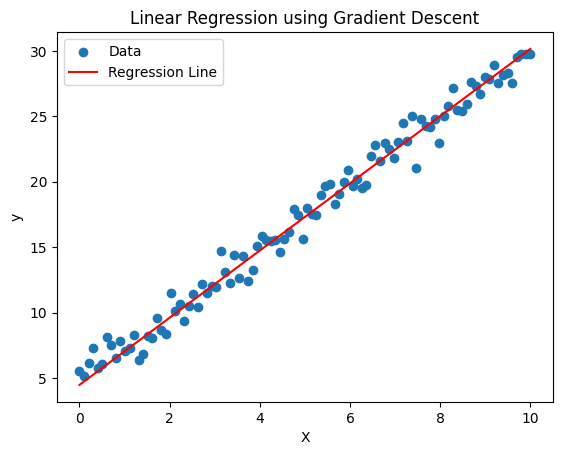

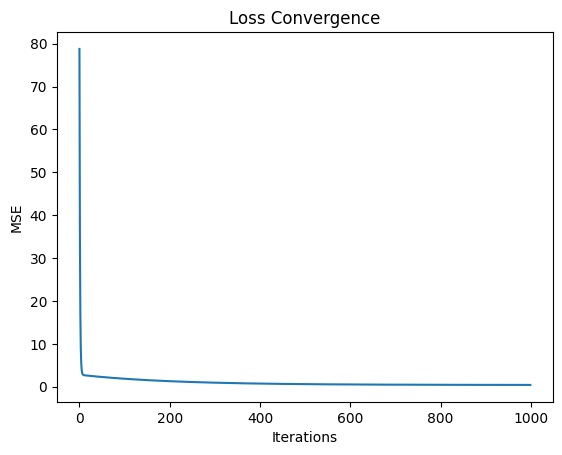

In [11]:
plt.scatter(X, y, label="Data")
plt.plot(X, theta1 * X + theta0, color="red", label="Regression Line")
plt.legend()
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression using Gradient Descent")
plt.show()

plt.plot(losses)
plt.xlabel("Iterations")
plt.ylabel("MSE")
plt.title("Loss Convergence")
plt.show()


In [12]:
import pandas as pd

data = pd.read_csv("advertising.csv")
print(data.head())
print(data.isnull().sum())
print(data.describe())


      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = data[["TV"]]
y = data["Sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [14]:
slr = LinearRegression()
slr.fit(X_train, y_train)

y_pred = slr.predict(X_test)

print("Intercept:", slr.intercept_)
print("Slope:", slr.coef_[0])


Intercept: 7.007108428241848
Slope: 0.0554829439314632


In [17]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


R2 Score: 0.802561303423698
MSE: 6.101072906773963


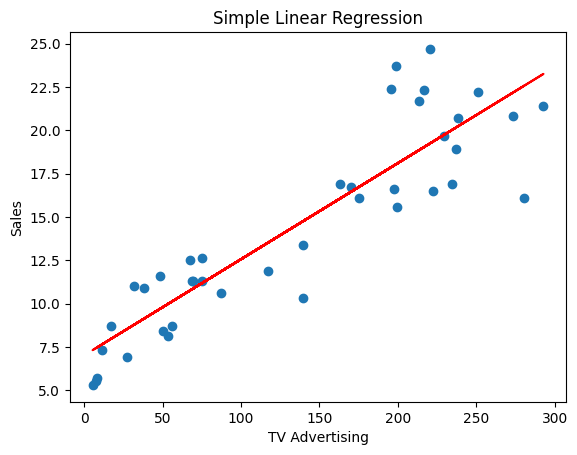

In [21]:
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred, color="red")
plt.xlabel("TV Advertising")
plt.ylabel("Sales")
plt.title("Simple Linear Regression")
plt.show()


In [23]:
X = data[["TV", "Radio", "Newspaper"]]
y = data["Sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

mlr = LinearRegression()
mlr.fit(X_train, y_train)

y_pred_mlr = mlr.predict(X_test)


In [25]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": mlr.coef_
})
print(coefficients)


     Feature  Coefficient
0         TV     0.054509
1      Radio     0.100945
2  Newspaper     0.004337


In [27]:
print("MLR R2:", r2_score(y_test, y_pred_mlr))
print("MLR MSE:", mean_squared_error(y_test, y_pred_mlr))


MLR R2: 0.9059011844150826
MLR MSE: 2.9077569102710896


In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

X_vif = X.values
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif, i) for i in range(X_vif.shape[1])]
print(vif_data)


     Feature       VIF
0         TV  2.486772
1      Radio  3.285462
2  Newspaper  3.055245


In [30]:
# problem statement 3
data = pd.read_csv("Car_Price.csv")
print(data.head())


     Brand                     Model  Year  Selling_Price  KM_Driven    Fuel  \
0   Maruti             Maruti 800 AC  2007          60000      70000  Petrol   
1   Maruti  Maruti Wagon R LXI Minor  2007         135000      50000  Petrol   
2  Hyundai      Hyundai Verna 1.6 SX  2012         600000     100000  Diesel   
3   Datsun    Datsun RediGO T Option  2017         250000      46000  Petrol   
4    Honda     Honda Amaze VX i-DTEC  2014         450000     141000  Diesel   

  Seller_Type Transmission         Owner  
0  Individual       Manual   First Owner  
1  Individual       Manual   First Owner  
2  Individual       Manual   First Owner  
3  Individual       Manual   First Owner  
4  Individual       Manual  Second Owner  


In [34]:

print(data.dtypes)


Brand            object
Model            object
Year              int64
Selling_Price     int64
KM_Driven         int64
Fuel             object
Seller_Type      object
Transmission     object
Owner            object
dtype: object


In [36]:
from sklearn.model_selection import train_test_split

print("Total samples:", len(data))



Total samples: 4340


In [38]:
data = data.drop(["Brand", "Model"], axis=1)


In [40]:
# Separate features and target
X = data.drop("Selling_Price", axis=1)
y = data["Selling_Price"].values.reshape(-1, 1)



In [42]:
data = pd.get_dummies(
    data,
    columns=["Fuel", "Seller_Type", "Transmission", "Owner"],
    drop_first=True
)


In [44]:
X = data.drop("Selling_Price", axis=1)
y = data["Selling_Price"].values.reshape(-1, 1)



In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [48]:
variances = pd.Series(X_scaled.var(axis=0), index=X.columns)

highest_var = variances.idxmax()
lowest_var = variances.idxmin()

print("Highest variance feature:", highest_var)
print("Lowest variance feature:", lowest_var)


Highest variance feature: Fuel_Electric
Lowest variance feature: KM_Driven


In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 3472
Testing samples: 868


In [52]:
m, n = X_train.shape
W = np.random.randn(n, 1)
b = 0


In [54]:
alpha = 0.01
epochs = 1500
losses = []

for _ in range(epochs):
    y_pred = X_train @ W + b
    error = y_pred - y_train

    dW = (1/m) * (X_train.T @ error)
    db = (1/m) * np.sum(error)

    W -= alpha * dW
    b -= alpha * db

    loss = (1/(2*m)) * np.sum(error**2)
    losses.append(loss)


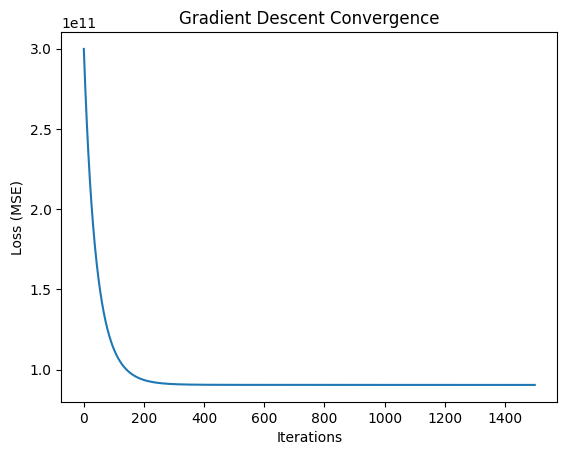

In [56]:
plt.plot(losses)
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Gradient Descent Convergence")
plt.show()


In [58]:
y_test_pred = X_test @ W + b


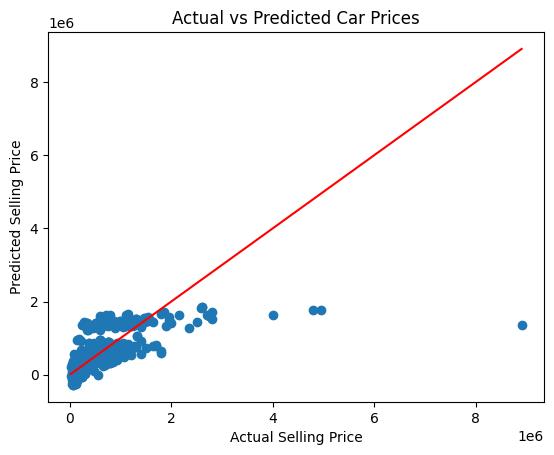

In [60]:
plt.scatter(y_test, y_test_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()
